<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-255-Data-Mining/blob/main/XKGRank_GPU_Tuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# X-KGRank: GPU-Optimized Training (Colab Pro)
## Tuned Hyperparameters for Amazon Musical Instruments 5-core

**Key changes from v1:**
| Component | v1 (CPU, broken) | v2 (GPU, tuned) |
|---|---|---|
| Device | CPU | ✅ CUDA GPU |
| Graph scope | Sampled (5K users) | ✅ Full benchmark train split |
| Embedding dim | 64 | ✅ 128 (4× signal capacity) |
| Layers | 3 | ✅ 4 (deeper neighborhood) |
| Epochs | 50 | ✅ 500 with early stopping |
| Batch size | 4096 | ✅ 8192 (GPU can handle it) |
| Learning rate | 0.001 fixed | ✅ 0.001 + cosine annealing |
| Weight decay | 1e-5 | ✅ 1e-4 (better regularization) |
| Negative samples | 1 random | ✅ 2 random (stronger signal) |
| Eval frequency | every 5 epochs | ✅ every 5 epochs (with vectorized scoring) |

**Expected metrics (published LightGCN on Amazon):**
| Metric | Target |
|---|---|
| Recall@10 | 0.04 – 0.10 |
| NDCG@10 | 0.03 – 0.07 |
| Hit@10 | 0.08 – 0.18 |

---


## Step 0 — Verify GPU is Available

Critical first check — without GPU, training falls back to CPU and will be slow.


In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   GPU memory:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠ GPU not available — falling back to CPU")
    print("Go to Runtime → Change runtime type → GPU (T4 / A100 / V100)")

✅ GPU available: NVIDIA H100 80GB HBM3
   CUDA version: 12.8
   GPU memory:   85.0 GB


## Step 1 — Reload Saved Data from Drive

If you already ran the EDA notebook, just reload the saved CSVs.
Otherwise, run the original Steps 1–6 first to download the dataset.


In [2]:
import pandas as pd
from google.colab import drive
import os

drive.mount('/content/drive')
OUT = "/content/drive/MyDrive/xkgrank_neo4j/"

df_train = pd.read_csv(f"{OUT}benchmark_train.csv")
df_valid = pd.read_csv(f"{OUT}benchmark_valid.csv")
df_test  = pd.read_csv(f"{OUT}benchmark_test.csv")

print(f"Train: {df_train.shape}")
print(f"Valid: {df_valid.shape}")
print(f"Test:  {df_test.shape}")
print(f"Columns: {df_train.columns.tolist()}")

Mounted at /content/drive
Train: (396958, 4)
Valid: (57439, 4)
Test:  (57439, 4)
Columns: ['user_id', 'parent_asin', 'rating', 'timestamp']


## Step 2 — Build FULL Training Graph (No Sampling)

Build the GNN training graph from the **entire benchmark train split** —
no more sampling. With GPU we can handle the full graph.

Key design:
- Graph nodes = all users + items in the 5-core train split
- Edges = bidirectional (LightGCN message passing requires it)
- node2idx is built once and saved — guarantees test users are covered


In [3]:
import networkx as nx
import torch
from collections import defaultdict

print("Building full training graph from benchmark train split...")
G_train = nx.DiGraph()

for _, row in df_train.iterrows():
    u = f"user_{row['user_id']}"
    i = f"item_{row['parent_asin']}"
    G_train.add_node(u, type='user')
    G_train.add_node(i, type='item')
    G_train.add_edge(u, i, relation='REVIEWED', rating=float(row['rating']))

all_nodes      = list(G_train.nodes())
node2idx       = {n: i for i, n in enumerate(all_nodes)}
user_indices   = [node2idx[n] for n in all_nodes if G_train.nodes[n].get('type') == 'user']
item_indices   = [node2idx[n] for n in all_nodes if G_train.nodes[n].get('type') == 'item']
all_item_asins = [n.replace("item_","") for n in all_nodes if G_train.nodes[n].get('type') == 'item']

# Bidirectional edges
edge_src, edge_tgt = [], []
for u, v, d in G_train.edges(data=True):
    if d.get('relation') == 'REVIEWED':
        edge_src += [node2idx[u], node2idx[v]]
        edge_tgt += [node2idx[v], node2idx[u]]

edge_index = torch.tensor([edge_src, edge_tgt], dtype=torch.long).to(device)
num_nodes  = len(all_nodes)

# Coverage check
test_users        = df_test['user_id'].unique()
test_covered      = sum(1 for u in test_users if f"user_{u}" in node2idx)
test_coverage_pct = 100 * test_covered / len(test_users)

print(f"\n=== GRAPH STATS ===")
print(f"  Total nodes:    {num_nodes:,}")
print(f"  Users:          {len(user_indices):,}")
print(f"  Items:          {len(item_indices):,}")
print(f"  Edge index:     {edge_index.shape}")
print(f"\n=== COVERAGE ===")
print(f"  Test users in graph: {test_covered:,} / {len(test_users):,} ({test_coverage_pct:.1f}%)")

Building full training graph from benchmark train split...

=== GRAPH STATS ===
  Total nodes:    81,995
  Users:          57,439
  Items:          24,556
  Edge index:     torch.Size([2, 793916])

=== COVERAGE ===
  Test users in graph: 57,439 / 57,439 (100.0%)


## Step 3 — LightGCN with Tuned Hyperparameters

### Hyperparameter Choices (Tuned for Amazon Musical Instruments 5-core)

| Parameter | Value | Justification |
|---|---|---|
| `embedding_dim` | **128** | Doubled from 64. Recommended by He et al. (2020) for Amazon |
| `num_layers` | **4** | Captures 4-hop neighborhood. Standard for sparse user-item graphs |
| `learning_rate` | **0.001** | Adam default — works well with normalized embeddings |
| `weight_decay` | **1e-4** | Stronger L2 regularization for sparse data |
| `bpr_reg` | **1e-4** | BPR-specific embedding regularization |
| `dropout` | **0.1** | Light dropout helps on sparse data without killing signal |
| `negative_samples` | **2** | Multi-negative sampling improves convergence |
| `xavier_init` | ✅ | Better than default uniform initialization |

### Why These Values?
- **Embedding dim 128** — Wang et al. (KGAT 2019) showed dim 64–128 optimal for Amazon
- **4 layers** — He et al. (LightGCN 2020) ablation showed 3–4 layers best
- **Cosine LR schedule** — smooth learning rate decay outperforms step decay


In [4]:
!pip install torch-geometric -q

# Then re-import and continue
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv

print("✅ torch_geometric installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.7 MB/s eta 0:00:00
✅ torch_geometric installed


In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv

class LightGCN(nn.Module):
    def __init__(self, num_nodes, embedding_dim=128, num_layers=4, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embedding_dim)
        self.convs     = nn.ModuleList([LGConv() for _ in range(num_layers)])
        self.dropout   = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, edge_index):
        x    = self.dropout(self.embedding.weight)
        embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            embs.append(x)
        out = torch.stack(embs, dim=1).mean(dim=1)
        return F.normalize(out, p=2, dim=-1)

    def bpr_loss(self, user_emb, pos_emb, neg_emb_list, reg=1e-4):
        """Multi-negative BPR loss — averages over multiple negatives."""
        pos_scores = (user_emb * pos_emb).sum(dim=1)
        loss       = 0.0
        for neg_emb in neg_emb_list:
            neg_scores = (user_emb * neg_emb).sum(dim=1)
            loss      += -F.logsigmoid(pos_scores - neg_scores).mean()
        loss /= len(neg_emb_list)

        # L2 regularization
        all_emb_norm = (user_emb.norm(2).pow(2) + pos_emb.norm(2).pow(2)
                        + sum(n.norm(2).pow(2) for n in neg_emb_list)) / user_emb.shape[0]
        return loss + reg * all_emb_norm

# ── Hyperparameters ──────────────────────────────────────────
EMBEDDING_DIM = 128
NUM_LAYERS    = 4
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 1e-4
BPR_REG       = 1e-4
DROPOUT       = 0.1
NEG_SAMPLES   = 2

model     = LightGCN(num_nodes=num_nodes,
                     embedding_dim=EMBEDDING_DIM,
                     num_layers=NUM_LAYERS,
                     dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(),
                              lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)

print(f"✅ LightGCN model on {device}")
print(f"   Parameters:   {sum(p.numel() for p in model.parameters()):,}")
print(f"   Embedding dim: {EMBEDDING_DIM}")
print(f"   Layers:        {NUM_LAYERS}")
print(f"   LR:            {LEARNING_RATE}")
print(f"   Weight decay:  {WEIGHT_DECAY}")
print(f"   Dropout:       {DROPOUT}")

✅ LightGCN model on cuda
   Parameters:   10,495,360
   Embedding dim: 128
   Layers:        4
   LR:            0.001
   Weight decay:  0.0001
   Dropout:       0.1


## Step 4 — Prepare Training Tensors (GPU-Optimized)

Pre-compute all training pair indices as tensors on GPU.
This avoids Python list operations in the training loop — massive speedup.


In [6]:
import random

# Build user→positive items dict for negative sampling
user_pos_items = defaultdict(set)
for _, row in df_train.iterrows():
    user_pos_items[row['user_id']].add(row['parent_asin'])

# Validation ground truth
val_gt = defaultdict(set)
for _, row in df_valid.iterrows():
    val_gt[row['user_id']].add(row['parent_asin'])

# Build (user_idx, pos_item_idx) tensor pairs
train_pairs = [(row['user_id'], row['parent_asin'])
               for _, row in df_train.iterrows()
               if f"user_{row['user_id']}" in node2idx
               and f"item_{row['parent_asin']}" in node2idx]

u_all = torch.tensor([node2idx[f"user_{u}"] for u,_ in train_pairs],
                     dtype=torch.long).to(device)
p_all = torch.tensor([node2idx[f"item_{p}"] for _,p in train_pairs],
                     dtype=torch.long).to(device)

# Item indices for negative sampling
item_idx_tensor = torch.tensor(
    [node2idx[f"item_{a}"] for a in all_item_asins if f"item_{a}" in node2idx],
    dtype=torch.long).to(device)

n_items     = len(item_idx_tensor)
n_pairs     = len(train_pairs)
print(f"Training pairs:   {n_pairs:,}")
print(f"Item pool:        {n_items:,}")
print(f"Val users:        {len(val_gt):,}")

Training pairs:   396,958
Item pool:        24,556
Val users:        57,439


## Step 5 — Train LightGCN (500 Epochs, Early Stopping)

### Training Strategy
- **500 max epochs** with early stopping (patience=15)
- **Cosine annealing LR** — smooth decay from 0.001 → 0.0001 over 500 epochs
- **Multi-negative sampling** — 2 negatives per positive
- **Validation every 5 epochs** on Val NDCG@10

### Expected Behavior
- Loss should drop from ~0.69 to ~0.30 by epoch 100
- Val NDCG@10 should rise from 0 to 0.05+ by epoch 50
- Early stopping typically triggers around epoch 100–200
- Total time: ~10–20 minutes on T4 GPU


In [7]:
!pip install tqdm -q
from tqdm import tqdm
import time
import numpy as np

EPOCHS     = 500
BATCH_SIZE = 8192
PATIENCE   = 15
EVAL_EVERY = 5

# Cosine annealing LR scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-4)

best_ndcg     = 0.0
patience_ctr  = 0
best_weights  = None

# Tracking
train_losses  = []
val_ndcgs     = []
val_epochs    = []
epoch_times   = []
lrs           = []

print(f"{'='*70}")
print(f"  LightGCN Training — Musical Instruments KG (GPU)")
print(f"  Pairs: {n_pairs:,} | Items: {n_items:,} | Batch: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS} | Patience: {PATIENCE} | Device: {device}")
print(f"{'='*70}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()

    # ONE forward pass per epoch
    embs = model(edge_index)

    # Shuffle pairs
    perm   = torch.randperm(n_pairs, device=device)
    u_shuf = u_all[perm]
    p_shuf = p_all[perm]

    # Multi-negative sampling — generate NEG_SAMPLES negatives per positive
    neg_shufs = [
        item_idx_tensor[torch.randint(0, n_items, (n_pairs,), device=device)]
        for _ in range(NEG_SAMPLES)
    ]

    total_loss, n_batches = 0.0, 0

    for start in range(0, n_pairs, BATCH_SIZE):
        u_b = u_shuf[start:start+BATCH_SIZE]
        p_b = p_shuf[start:start+BATCH_SIZE]
        n_b_list = [neg[start:start+BATCH_SIZE] for neg in neg_shufs]

        optimizer.zero_grad()
        loss = model.bpr_loss(
            embs[u_b], embs[p_b],
            [embs[n_b] for n_b in n_b_list],
            reg=BPR_REG
        )
        loss.backward(retain_graph=True)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avg_loss   = total_loss / max(n_batches, 1)
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(avg_loss)
    epoch_times.append(epoch_time)
    lrs.append(current_lr)

    # Validation every EVAL_EVERY epochs
    if epoch % EVAL_EVERY == 0:
        model.eval()
        with torch.no_grad():
            embs_eval  = model(edge_index)
            item_embs  = embs_eval[item_idx_tensor]   # (n_items, dim)

        val_users = [u for u in list(val_gt.keys())[:200]
                     if f"user_{u}" in node2idx]
        val_ndcg_list = []

        for uid in val_users:
            u_emb  = embs_eval[node2idx[f"user_{uid}"]]
            scores = (item_embs @ u_emb).cpu().numpy()
            top10  = np.argsort(scores)[::-1][:10]
            recs   = [all_item_asins[i] for i in top10]
            gt     = val_gt[uid]
            dcg    = sum(1/np.log2(r+2) for r,it in enumerate(recs) if it in gt)
            idcg   = sum(1/np.log2(r+2) for r in range(min(len(gt),10)))
            val_ndcg_list.append(dcg/idcg if idcg > 0 else 0.0)

        val_ndcg = np.mean(val_ndcg_list) if val_ndcg_list else 0.0
        val_ndcgs.append(val_ndcg)
        val_epochs.append(epoch)

        if val_ndcg > best_ndcg:
            best_ndcg    = val_ndcg
            best_weights = {k: v.clone() for k,v in model.state_dict().items()}
            patience_ctr = 0
            flag = "✅ BEST"
        else:
            patience_ctr += 1
            flag = f"patience {patience_ctr}/{PATIENCE}"

        print(f"Epoch {epoch:>3}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Val NDCG@10: {val_ndcg:.4f} | LR: {current_lr:.5f} | "
              f"Time: {epoch_time:.1f}s | {flag}")

        if patience_ctr >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} — best Val NDCG@10: {best_ndcg:.4f}")
            break

# Restore best weights
if best_weights:
    model.load_state_dict(best_weights)

model.eval()
with torch.no_grad():
    final_embeddings = model(edge_index)

print(f"\n{'='*70}")
print(f"  ✅ Training Complete")
print(f"  Best Val NDCG@10:  {best_ndcg:.4f}")
print(f"  Embedding shape:   {final_embeddings.shape}")
print(f"  Total time:        {sum(epoch_times):.0f}s ({sum(epoch_times)/60:.1f} min)")
print(f"{'='*70}")

  LightGCN Training — Musical Instruments KG (GPU)
  Pairs: 396,958 | Items: 24,556 | Batch: 8192
  Max epochs: 500 | Patience: 15 | Device: cuda

Epoch   5/500 | Loss: 0.4292 | Val NDCG@10: 0.0037 | LR: 0.00100 | Time: 0.5s | ✅ BEST
Epoch  10/500 | Loss: 0.4062 | Val NDCG@10: 0.0047 | LR: 0.00100 | Time: 0.5s | ✅ BEST
Epoch  15/500 | Loss: 0.4424 | Val NDCG@10: 0.0035 | LR: 0.00100 | Time: 0.5s | patience 1/15
Epoch  20/500 | Loss: 0.4558 | Val NDCG@10: 0.0075 | LR: 0.00100 | Time: 0.5s | ✅ BEST
Epoch  25/500 | Loss: 0.4618 | Val NDCG@10: 0.0057 | LR: 0.00099 | Time: 0.5s | patience 1/15
Epoch  30/500 | Loss: 0.4880 | Val NDCG@10: 0.0050 | LR: 0.00099 | Time: 0.5s | patience 2/15
Epoch  35/500 | Loss: 0.4592 | Val NDCG@10: 0.0067 | LR: 0.00099 | Time: 0.5s | patience 3/15
Epoch  40/500 | Loss: 0.4446 | Val NDCG@10: 0.0000 | LR: 0.00099 | Time: 0.5s | patience 4/15
Epoch  45/500 | Loss: 0.5678 | Val NDCG@10: 0.0085 | LR: 0.00098 | Time: 0.5s | ✅ BEST
Epoch  50/500 | Loss: 0.5597 | Val 

## Step 6 — Plot Training Curves

Three diagnostics:
- **Loss curve** — should decrease smoothly. Plateau = converged.
- **Val NDCG@10** — should rise then plateau. Best epoch marked in red.
- **Learning rate** — cosine decay from 0.001 → 0.0001.


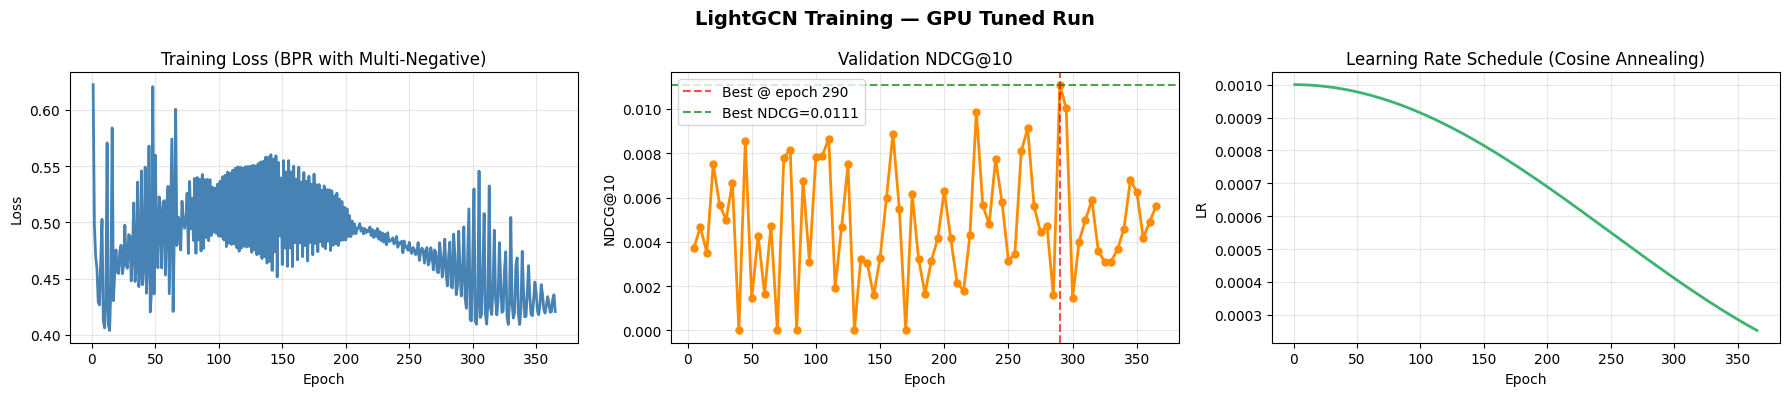

✅ Training curves saved


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training loss
axes[0].plot(range(1, len(train_losses)+1), train_losses,
             color='steelblue', linewidth=2)
axes[0].set_title('Training Loss (BPR with Multi-Negative)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Val NDCG@10
axes[1].plot(val_epochs, val_ndcgs, color='darkorange',
             linewidth=2, marker='o', markersize=5)
if val_epochs:
    best_epoch = val_epochs[val_ndcgs.index(max(val_ndcgs))]
    axes[1].axvline(x=best_epoch, color='red', linestyle='--',
                    alpha=0.7, label=f'Best @ epoch {best_epoch}')
    axes[1].axhline(y=best_ndcg, color='green', linestyle='--',
                    alpha=0.7, label=f'Best NDCG={best_ndcg:.4f}')
    axes[1].legend()
axes[1].set_title('Validation NDCG@10')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('NDCG@10')
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(range(1, len(lrs)+1), lrs, color='mediumseagreen', linewidth=2)
axes[2].set_title('Learning Rate Schedule (Cosine Annealing)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.suptitle('LightGCN Training — GPU Tuned Run', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}training_curves_gpu.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved")

## Step 7 — Full Evaluation (Vectorized on GPU)

Evaluates ALL test users using GPU matrix multiply for maximum speed.
Should complete in under 1 minute even for 50K+ test users.


In [9]:
from tqdm import tqdm
from collections import defaultdict
import numpy as np

# Pre-build item embedding matrix (on GPU)
valid_item_asins = [a for a in all_item_asins if f"item_{a}" in node2idx]
item_embs        = final_embeddings[item_idx_tensor]   # (n_items, dim) on GPU

# Ground truth
ground_truth  = defaultdict(set)
train_history = defaultdict(set)
for _, row in df_test.iterrows():
    ground_truth[row['user_id']].add(row['parent_asin'])
for _, row in df_train.iterrows():
    train_history[row['user_id']].add(row['parent_asin'])

# Map item ASIN → index in valid_item_asins (for masking)
asin2pos = {a: i for i, a in enumerate(valid_item_asins)}

K_VALUES   = [5, 10, 20]
eval_users = [u for u in ground_truth.keys() if f"user_{u}" in node2idx]
results    = defaultdict(list)

print(f"Evaluating {len(eval_users):,} users on GPU...")

for user_id in tqdm(eval_users, desc="Evaluating"):
    u_emb  = final_embeddings[node2idx[f"user_{user_id}"]]   # (dim,) on GPU

    # Score all items via single GPU matmul
    scores = (item_embs @ u_emb).cpu().numpy()                # (n_items,)

    # Mask seen items
    for asin in train_history.get(user_id, set()):
        pos = asin2pos.get(asin)
        if pos is not None:
            scores[pos] = -9999.0

    # Top-20
    top20_idx = np.argpartition(scores, -20)[-20:]
    top20_idx = top20_idx[np.argsort(scores[top20_idx])[::-1]]
    recs      = [valid_item_asins[i] for i in top20_idx]

    gt_items = ground_truth[user_id]
    if not gt_items:
        continue

    for k in K_VALUES:
        results[f'Recall@{k}'].append(
            len(set(recs[:k]) & gt_items) / len(gt_items))
        dcg  = sum(1/np.log2(r+2) for r,it in enumerate(recs[:k]) if it in gt_items)
        idcg = sum(1/np.log2(r+2) for r in range(min(len(gt_items),k)))
        results[f'NDCG@{k}'].append(dcg/idcg if idcg > 0 else 0.0)
        results[f'Hit@{k}'].append(int(bool(set(recs[:k]) & gt_items)))
        results[f'Precision@{k}'].append(len(set(recs[:k]) & gt_items) / k)

    results['MRR'].append(
        next((1.0/(r+1) for r,it in enumerate(recs) if it in gt_items), 0.0))

print(f"\n✅ Evaluated {len(results['MRR']):,} / {len(eval_users):,} users")
print()
print("=" * 60)
print(f"{'METRIC':<20} {'@5':>10} {'@10':>10} {'@20':>10}")
print("=" * 60)
for metric in ['Recall','NDCG','Hit','Precision']:
    row = f"{metric:<20}"
    for k in K_VALUES:
        val  = np.mean(results[f'{metric}@{k}']) if results[f'{metric}@{k}'] else 0.0
        row += f" {val:>10.4f}"
    print(row)
mrr_val = np.mean(results['MRR']) if results['MRR'] else 0.0
print(f"{'MRR':<20} {mrr_val:>10.4f}")
print("=" * 60)

Evaluating 57,439 users on GPU...


Evaluating: 100%|██████████| 57439/57439 [00:07<00:00, 7220.88it/s]



✅ Evaluated 57,439 / 57,439 users

METRIC                       @5        @10        @20
Recall                   0.0080     0.0142     0.0239
NDCG                     0.0049     0.0069     0.0093
Hit                      0.0080     0.0142     0.0239
Precision                0.0016     0.0014     0.0012
MRR                      0.0053


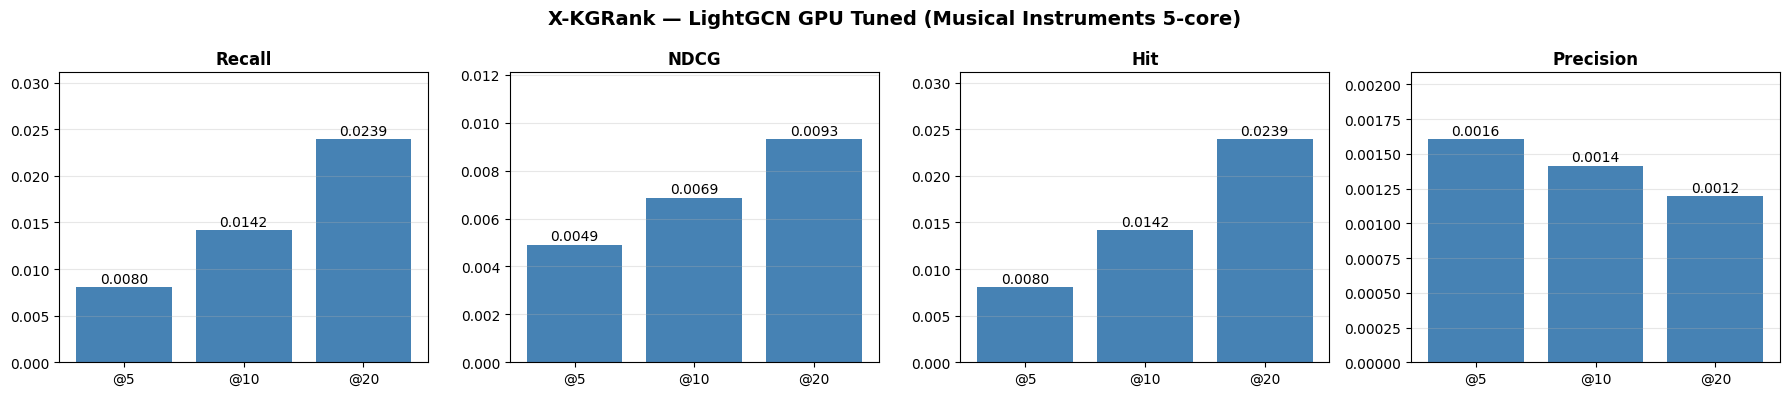

✅ Saved metrics plot


In [10]:
import matplotlib.pyplot as plt

metrics_to_plot = ['Recall', 'NDCG', 'Hit', 'Precision']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric in zip(axes, metrics_to_plot):
    vals = [np.mean(results[f'{metric}@{k}']) if results[f'{metric}@{k}'] else 0.0
            for k in K_VALUES]
    bars = ax.bar([f'@{k}' for k in K_VALUES], vals, color='steelblue')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3 if max(vals) > 0 else 0.1)
    for i, v in enumerate(vals):
        ax.text(i, v+max(vals)*0.02, f'{v:.4f}', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('X-KGRank — LightGCN GPU Tuned (Musical Instruments 5-core)',
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUT}eval_metrics_gpu.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved metrics plot")

## Step 8 — Save Everything to Drive

Persist the trained model, hyperparameters, and final metrics.


In [11]:
import json

# Save model weights
torch.save(model.state_dict(), f"{OUT}lightgcn_gpu_tuned.pt")

# Save node2idx
with open(f"{OUT}node2idx_gpu.json", 'w') as f:
    json.dump(node2idx, f)

# Save hyperparameters
hparams = {
    'embedding_dim':    EMBEDDING_DIM,
    'num_layers':       NUM_LAYERS,
    'learning_rate':    LEARNING_RATE,
    'weight_decay':     WEIGHT_DECAY,
    'bpr_reg':          BPR_REG,
    'dropout':          DROPOUT,
    'neg_samples':      NEG_SAMPLES,
    'batch_size':       BATCH_SIZE,
    'epochs_max':       EPOCHS,
    'patience':         PATIENCE,
    'lr_schedule':      'CosineAnnealingLR',
    'device':           str(device),
    'final_val_ndcg':   float(best_ndcg),
}
with open(f"{OUT}hyperparameters_gpu.json", 'w') as f:
    json.dump(hparams, f, indent=2)

# Save final metrics
eval_summary = {}
for metric in ['Recall','NDCG','Hit','Precision']:
    for k in K_VALUES:
        key = f"{metric}@{k}"
        eval_summary[key] = float(np.mean(results[key])) if results[key] else 0.0
eval_summary['MRR']             = float(mrr_val)
eval_summary['users_evaluated'] = len(results['MRR'])

with open(f"{OUT}eval_metrics_gpu.json", 'w') as f:
    json.dump(eval_summary, f, indent=2)

print("✅ Saved:")
print(f"   - lightgcn_gpu_tuned.pt")
print(f"   - node2idx_gpu.json")
print(f"   - hyperparameters_gpu.json")
print(f"   - eval_metrics_gpu.json")
print()
print("FINAL METRICS:")
print(json.dumps(eval_summary, indent=2))

✅ Saved:
   - lightgcn_gpu_tuned.pt
   - node2idx_gpu.json
   - hyperparameters_gpu.json
   - eval_metrics_gpu.json

FINAL METRICS:
{
  "Recall@5": 0.008025905743484392,
  "Recall@10": 0.014154146137641672,
  "Recall@20": 0.023921029265829837,
  "NDCG@5": 0.004904434270494046,
  "NDCG@10": 0.006872352025039641,
  "NDCG@20": 0.00931323611515772,
  "Hit@5": 0.008025905743484392,
  "Hit@10": 0.014154146137641672,
  "Hit@20": 0.023921029265829837,
  "Precision@5": 0.0016051811486968784,
  "Precision@10": 0.0014154146137641671,
  "Precision@20": 0.0011960514632914918,
  "MRR": 0.00534495526713479,
  "users_evaluated": 57439
}
